# North Qoroq ca. 1275 Ma paleomagnetic pole

## Geologic Context

- Terrane: Laurentia-Greenland.
- Compiled unit/pole label: North Qoroq Intrusion

## Paleomagnetic And Rock Magnetic Data

- B = 12 sites, N = 65 samples; mean direction DEC/INC = 295.7°/2.5°; K = 15.0.
- Rock-magnetic interpretation: expand with mineral carriers/coercivity/unblocking evidence from source studies.

## Age Constraints

- Current bracket: lomagage 1274.0 Ma, himagage 1276.0 Ma.
- Compilation method note: 1275.3±1.1 Ma U-Pb and 2 sigma uncertainty date from Upton 2003 from the Motzfeldt complex which is adjacent to the North Qoroq intrusion. Upton et al., 2003 interpreted that the date support a previous data of 1268±60 Ma Rb-Sr date from North Qoroq.


## References

- Paleomagnetic source: Piper, J.D.A. (1992). The palaeomagnetism of major (Middle Proterozoic) igneous complexes, South Greenland and the Gardar apparent polar wander track. Precambrian Res., 54, 153-172.
- Geochronology / age-constraint note (compilation): 1275.3±1.1 Ma U-Pb and 2 sigma uncertainty date from Upton 2003. measurement data never published and not sure what material was used
- Upton, B. (2003). Magmatism of the mid-Proterozoic Gardar Province, South Greenland: Chronology, petrogenesis and geological setting. Lithos, 68(1–2), 43–65. https://doi.org/10.1016/s0024-4937(03)00030-6
- Blaxland, A.B., van Breemen, O., Emeleus, C.H., Anderson, J.G., 1978. Age and origin of the major syenite centres in the Gardar Province of South Greenland: Rb – Sr studies. Geol. Soc. Amer. Bull. 89, 231 – 244.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Pole from the Evans et al. (2021) compilation

The pole is read directly from the previous Nordic compilation (`data/Evans_et_al_2021_compilation.csv`). No site-level recomputation is performed because the underlying directions are not digitized in this repository; the published pole is carried forward into the Nordic compilation format.

In [2]:
evans = pd.read_csv('../data/Evans_et_al_2021_compilation.csv')
row = evans[evans['ROCKNAME'] == 'North Qoroq Intr.'].iloc[0]

pole_mean = {'dec': float(row['PLONG']), 'inc': float(row['PLAT']),
             'alpha95': float(row['A95']), 'n': int(float(row['B']))}
dir_mean = {'dec': float(row['DEC']), 'inc': float(row['INC']),
            'alpha95': float(row['ED95']), 'k': float(row['KD'])}

print('North Qoroq Intrusion' + ' pole (Evans et al., 2021 compilation):')
print(f"  PLAT {pole_mean['inc']}  PLON {pole_mean['dec']}  A95 {pole_mean['alpha95']}  B {pole_mean['n']} sites")
print(f"  mean direction Dec {dir_mean['dec']}  Inc {dir_mean['inc']}  (%REV {row['%REV']})")

North Qoroq Intrusion pole (Evans et al., 2021 compilation):
  PLAT 13.2  PLON 202.6  A95 8.3  B 12 sites
  mean direction Dec 295.7  Inc 2.5  (%REV 8or92)


## Statistical assessment (Meert et al., 2020; R2)

In [3]:
pt.R2_test('North Qoroq Intr.', Laurentia_poles)

N = 65 (N ≥ 25; sufficient sample number);
B = 12 (B ≥ 8; sufficient site number);
K = 15 (70 ≥ K ≥ 10; meets PSV criteria);
A_95 of 8.3 passes Deenen et al. (2011) criteria of being between 4.4 and 17.1 for this number of sites


## Euler rotation into the Laurentia reference frame

These rocks belong to the Laurentia-Greenland terrane, so the pole must be restored into the Laurentia reference frame before it is compared with the Laurentia APWP. The Greenland-to-Laurentia rotation of Roest & Srivastava (1989), associated with Cenozoic opening of Baffin Bay and the Labrador Sea, is applied with `pmag.pt_rot`: Euler pole 67.5 deg N / -118.5 deg E, angle -13.8 deg. This is the same rotation `get_Laurentia_poles` uses to place the Greenland comparison poles into Laurentia coordinates.

In [4]:
euler_greenland = pt.TERRANE_EULER_POLES['Laurentia-Greenland']   # [67.5, -118.5, -13.8]; Roest & Srivastava (1989)
rlat, rlon = pmag.pt_rot(euler_greenland, [pole_mean['inc']], [pole_mean['dec']])
pole_rotated = {'inc': rlat[0], 'dec': rlon[0], 'alpha95': pole_mean['alpha95']}
print(f"unrotated (present-day Greenland frame): {pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E")
print(f"rotated into the Laurentia frame:        {pole_rotated['inc']:.1f} N / {pole_rotated['dec']:.1f} E")

unrotated (present-day Greenland frame): 13.2 N / 202.6 E
rotated into the Laurentia frame:        16.9 N / 190.8 E


## Position within the Laurentia apparent polar wander path

The pole is shown in its unrotated position (present-day Greenland coordinates, off the Laurentia path) and rotated into the Laurentia frame (restored onto the path). The comparison APWP poles are all shown in Laurentia coordinates.

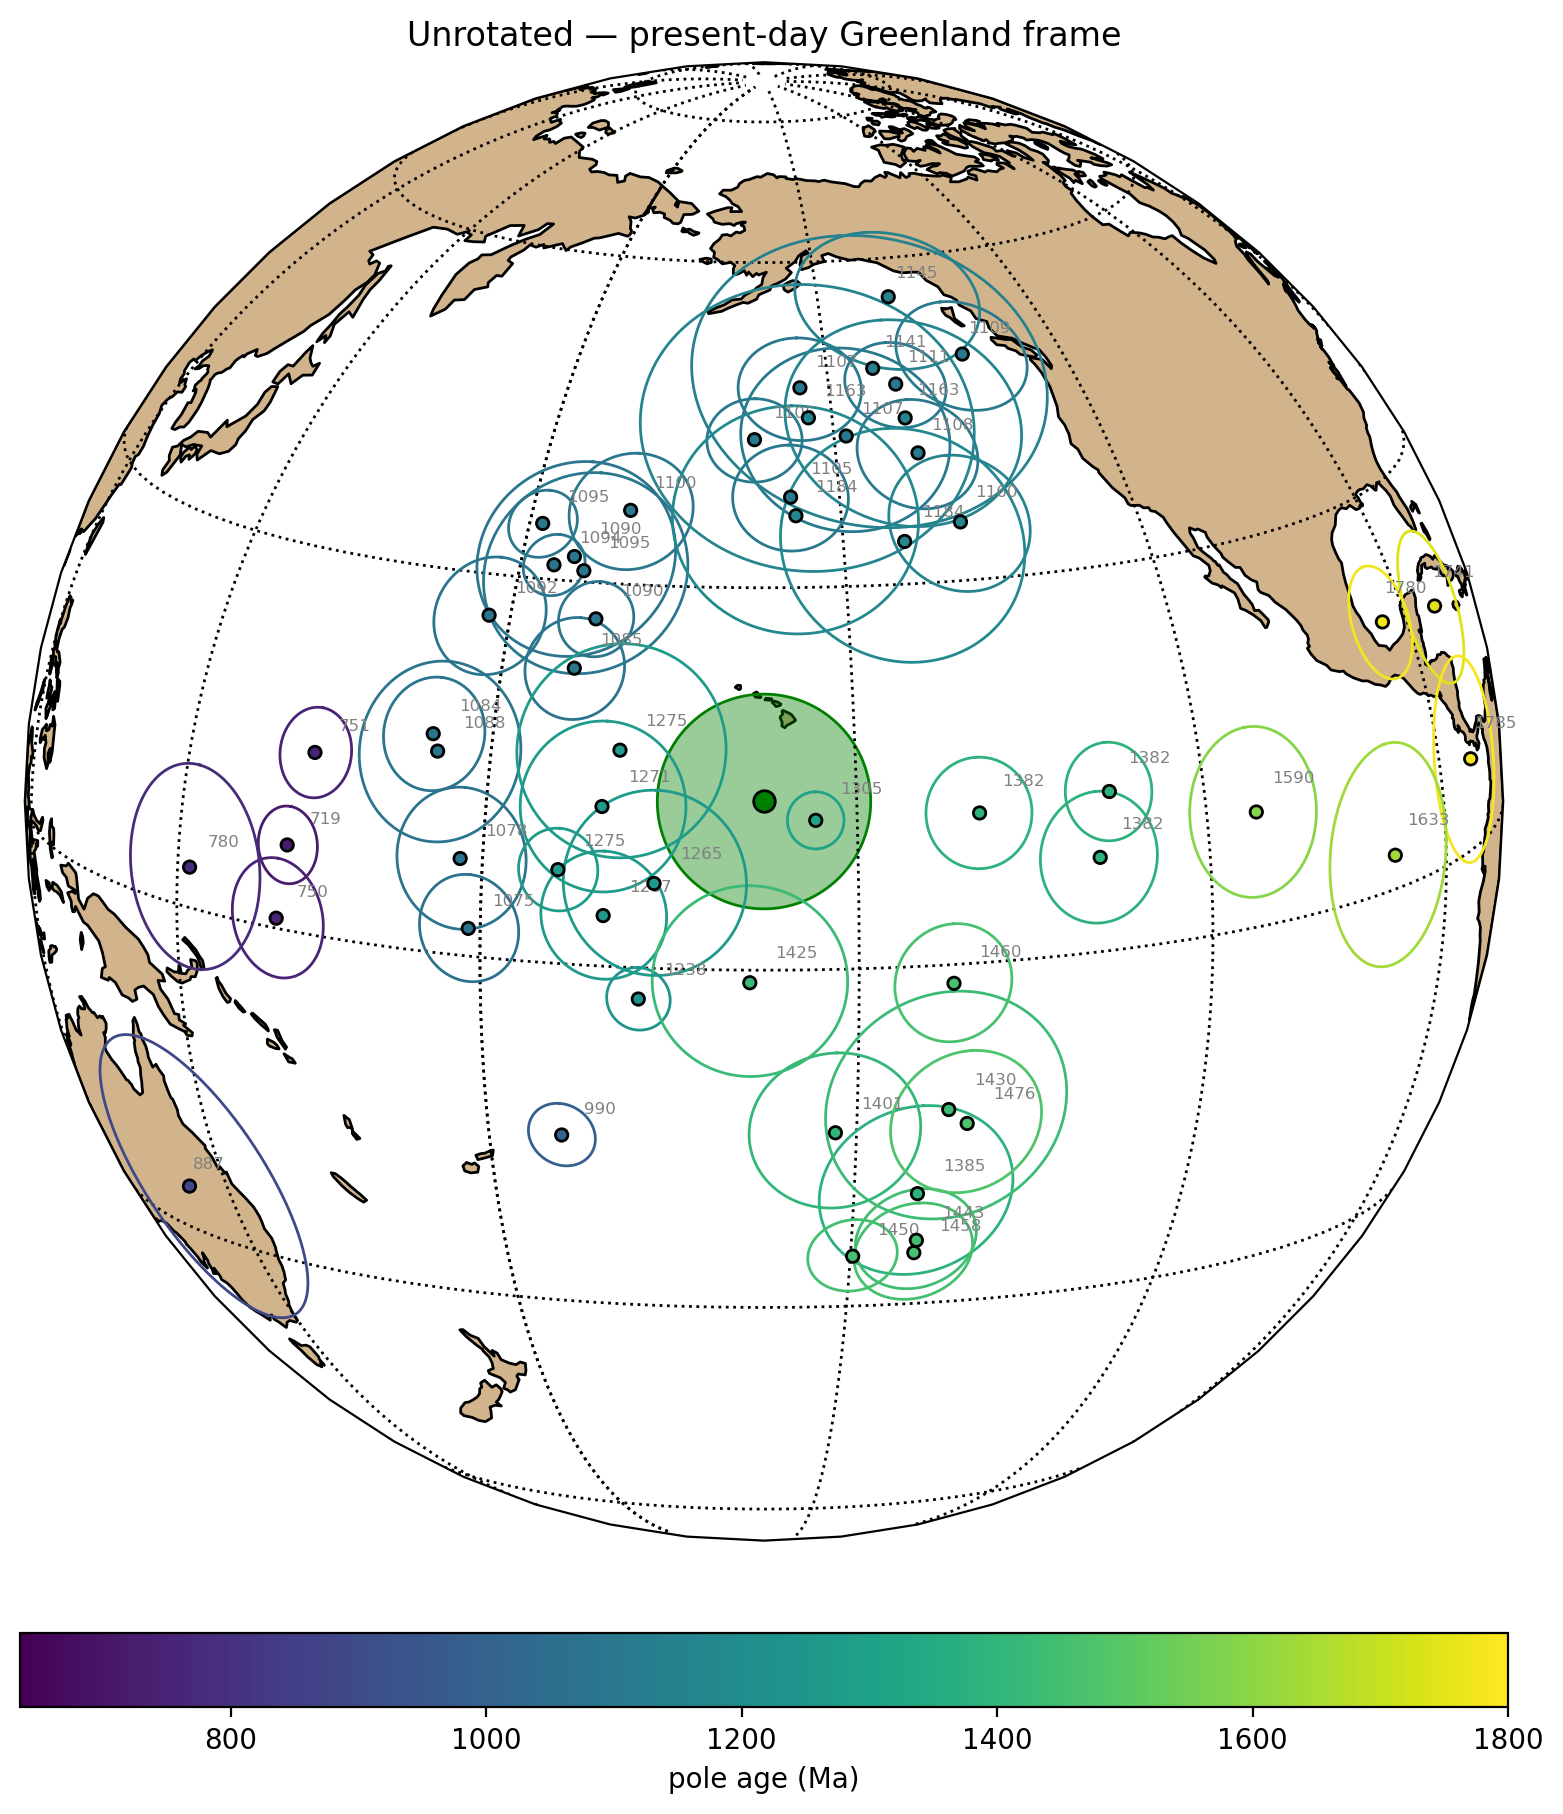

In [5]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.title('Unrotated \u2014 present-day Greenland frame')
plt.show()

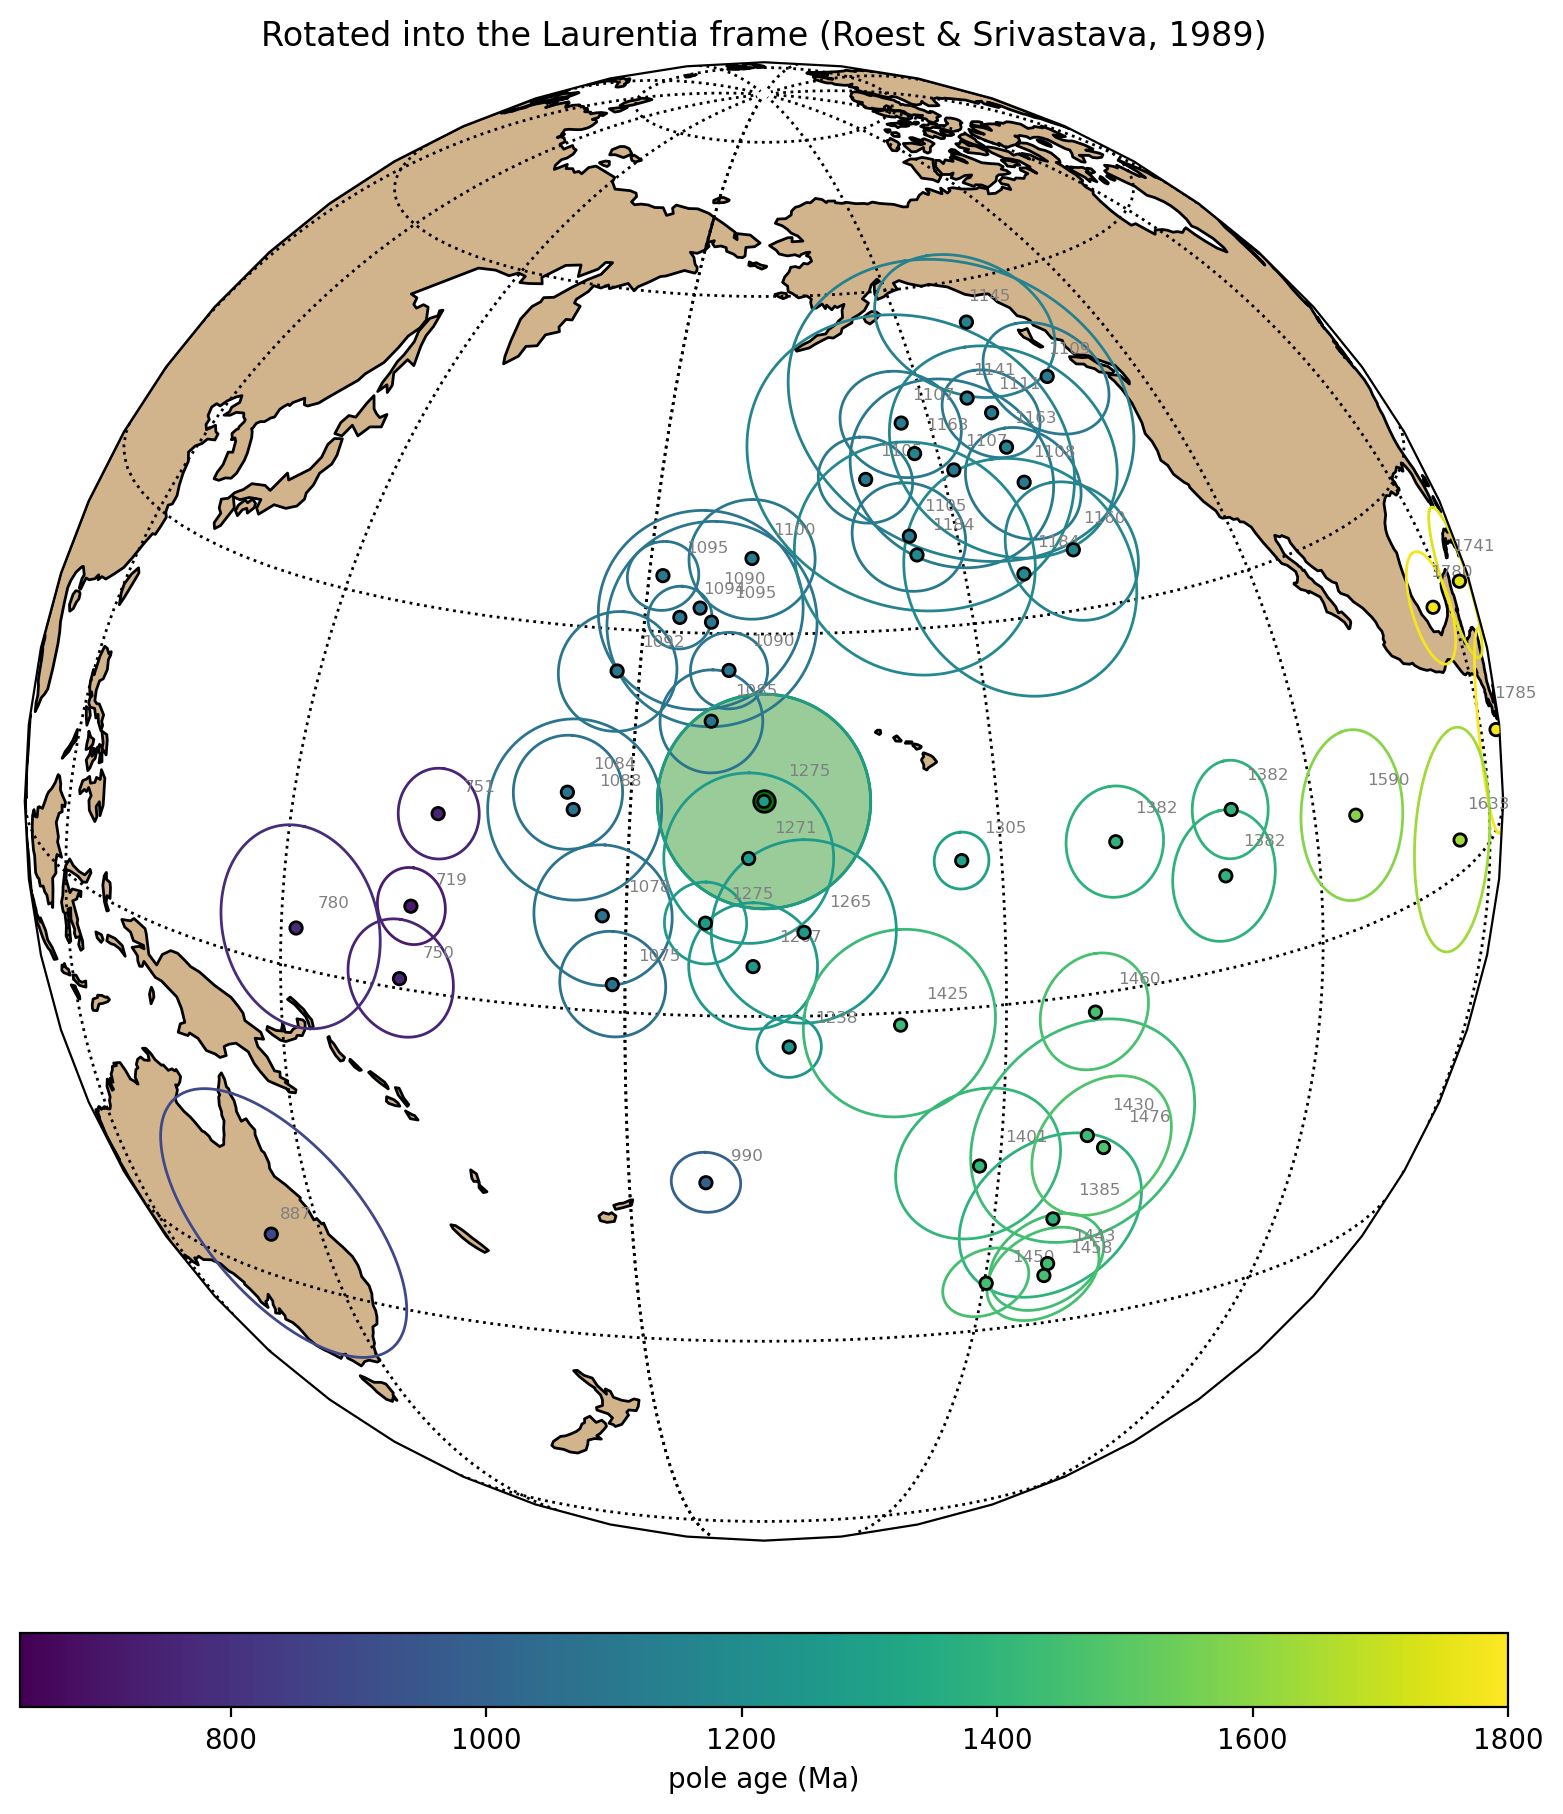

In [6]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_rotated['inc'], pole_rotated['dec'],
                          pole_rotated['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_rotated['dec'],
                          central_latitude=pole_rotated['inc'])
plt.title('Rotated into the Laurentia frame (Roest & Srivastava, 1989)')
plt.show()

## Comparison with younger Laurentia poles

The `plot_pole_overlap` comparison is shown for both the unrotated and the rotated position.

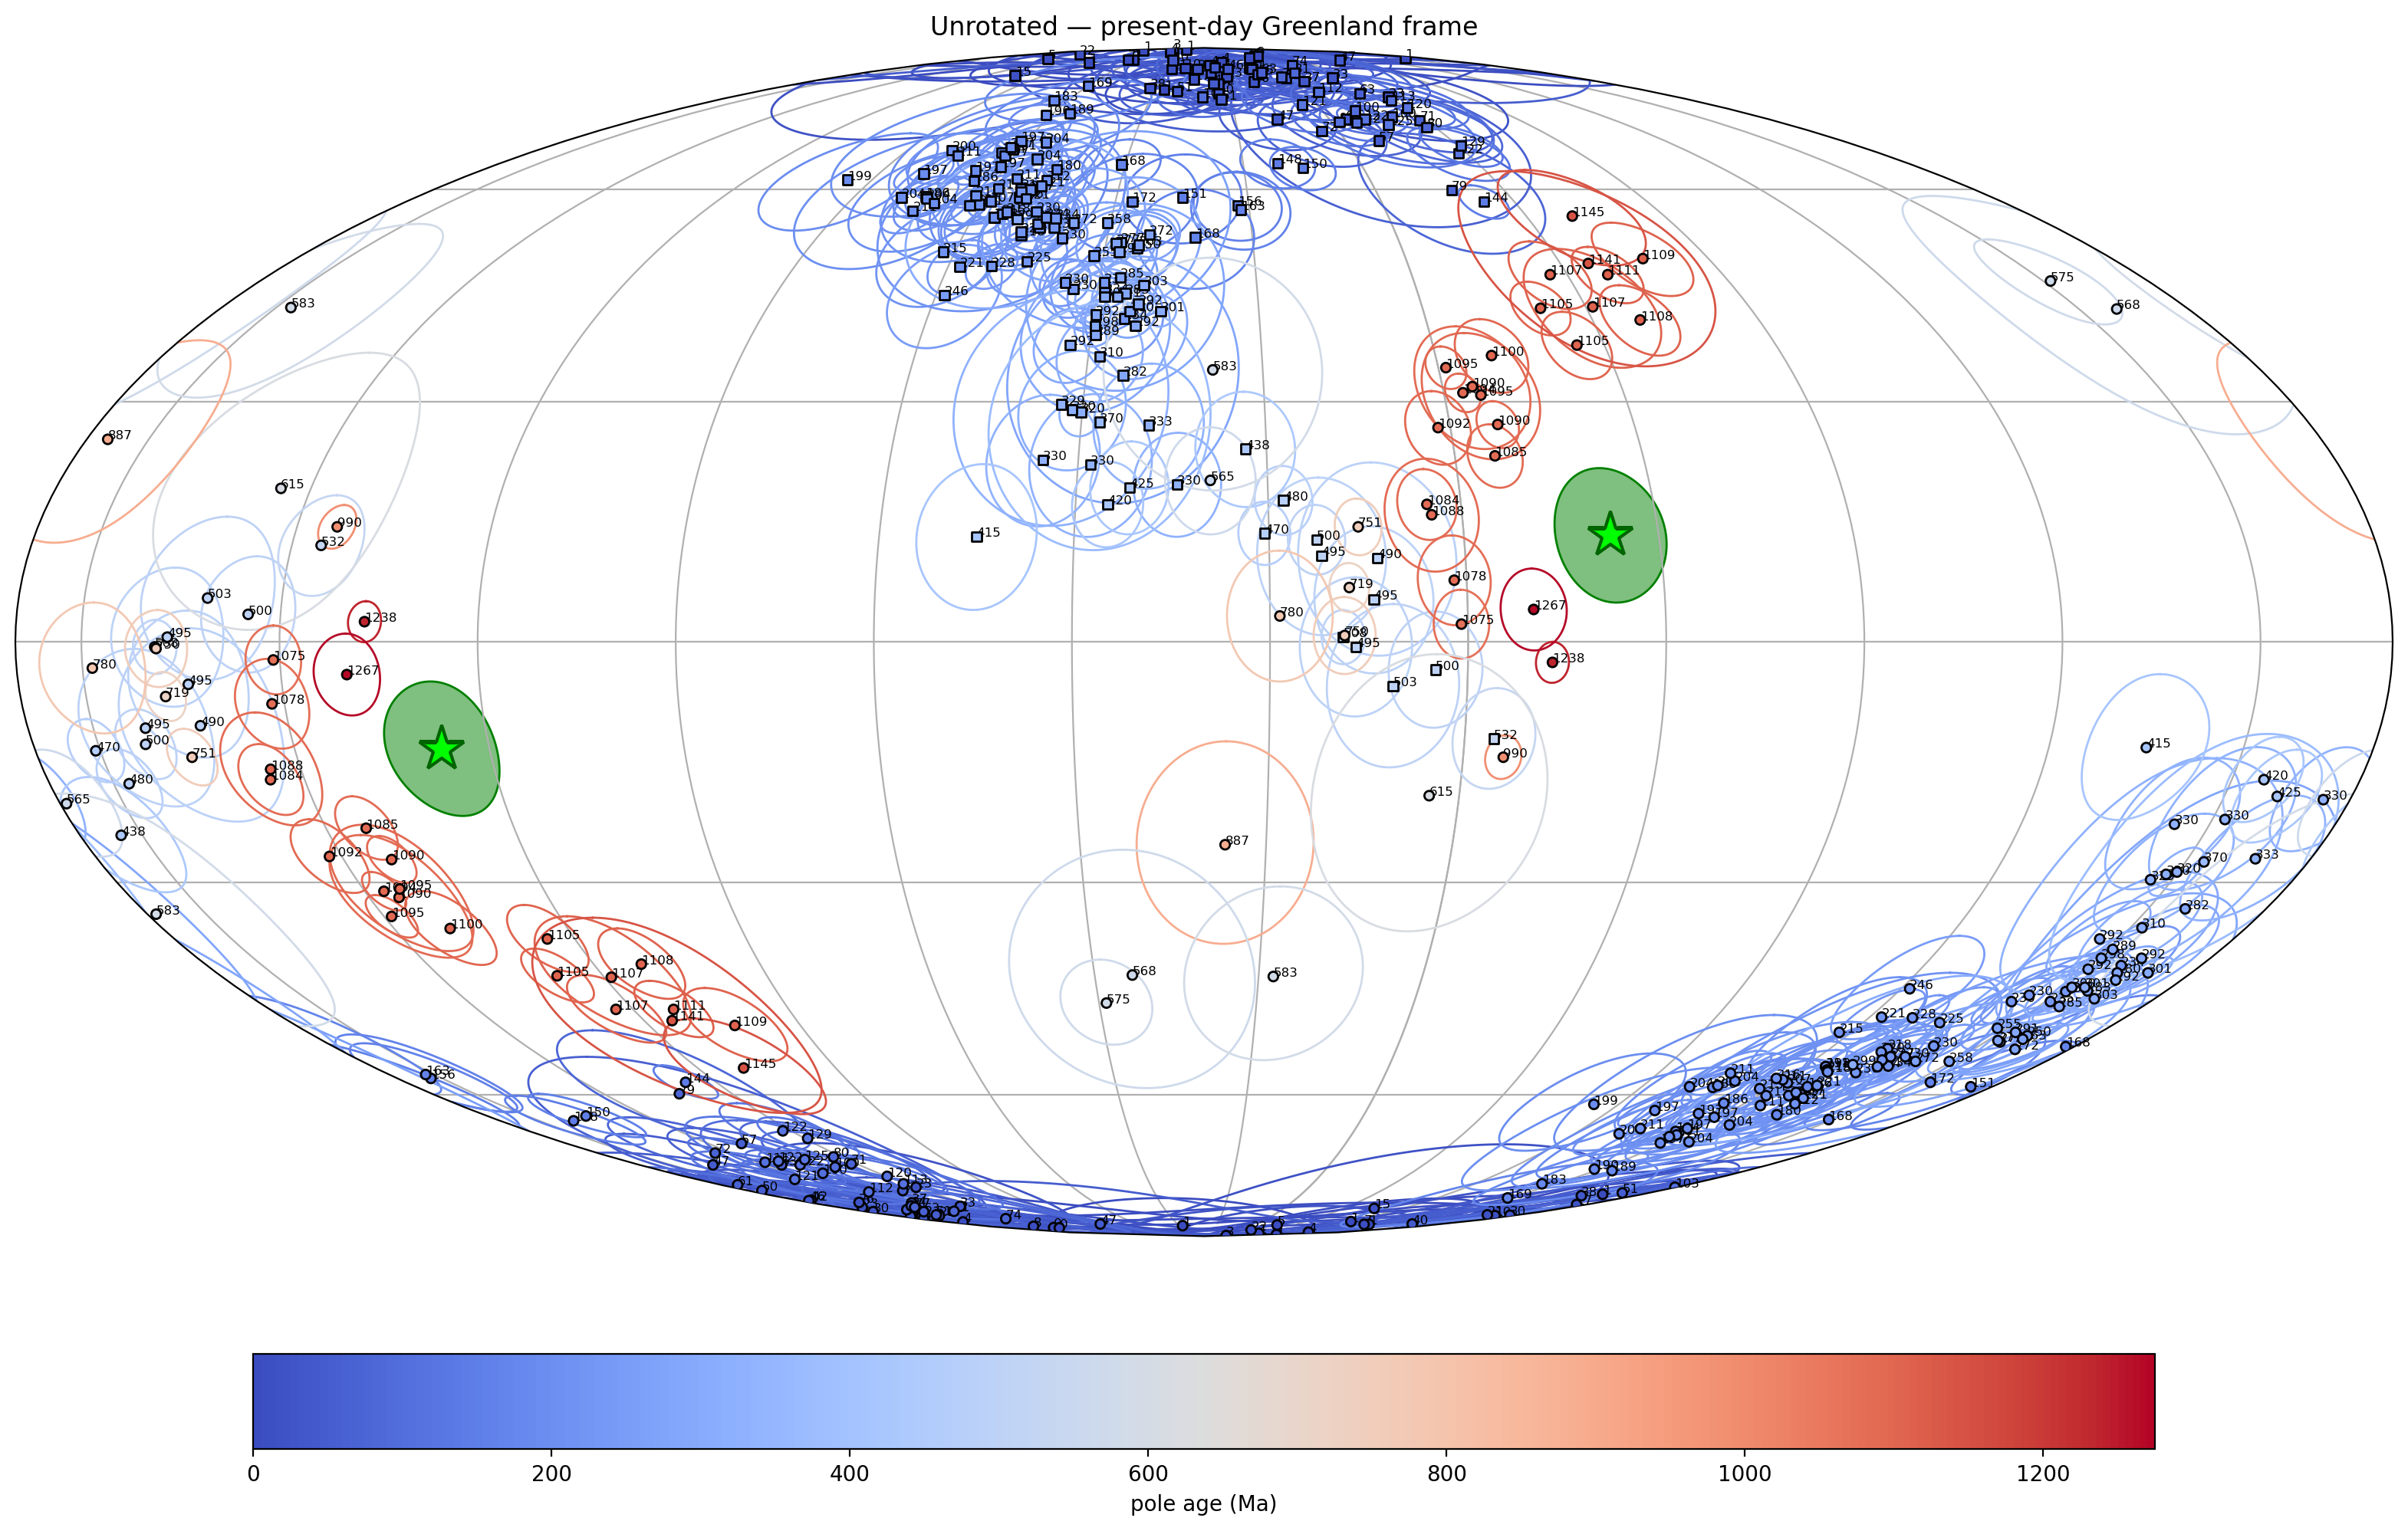

In [7]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('North Qoroq Intr.', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1275, show=False)
plt.title('Unrotated \u2014 present-day Greenland frame')
plt.show()

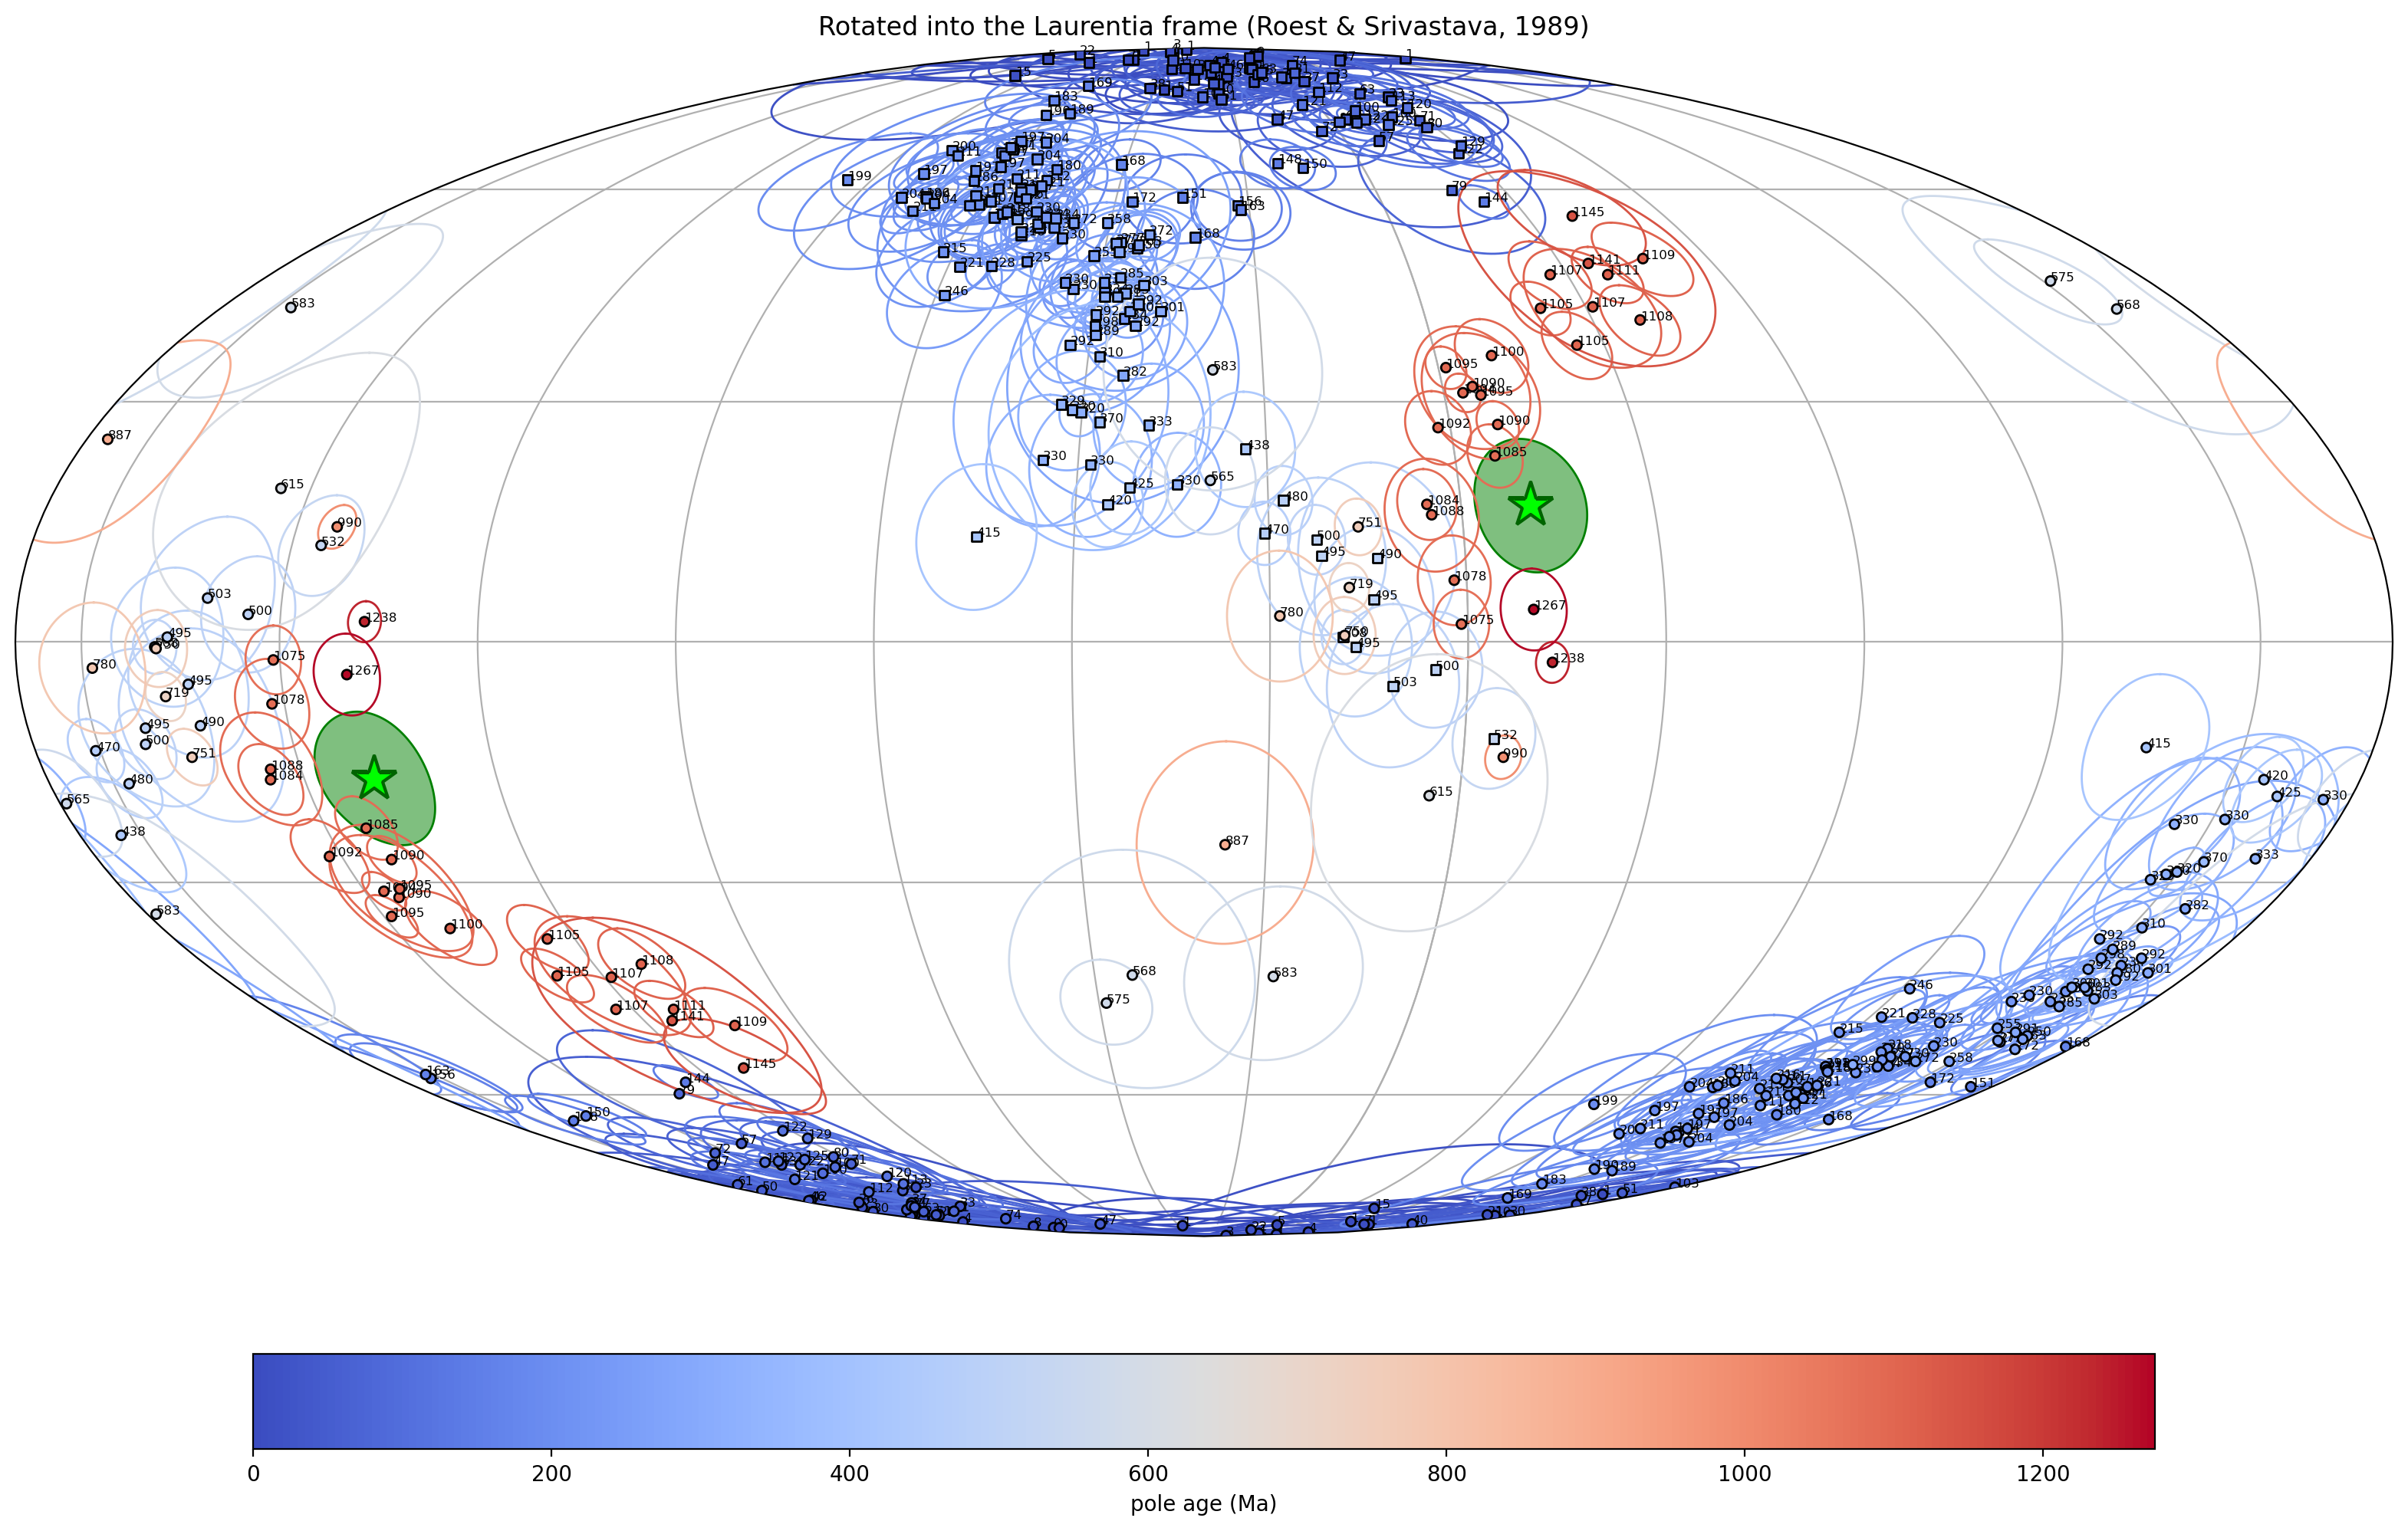

In [8]:
pt.plot_pole_overlap('North Qoroq Intr.', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_rotated['inc'], pole_plon=pole_rotated['dec'],
                     pole_A95=pole_rotated['alpha95'], pole_age=1275, show=False)
plt.title('Rotated into the Laurentia frame (Roest & Srivastava, 1989)')
plt.show()

## Nordic workshop summary

The pole is exported in the Nordic compilation format. The R-criteria scores, pole position, mean direction, and source-publication metadata are carried from the Evans et al. (2021) compilation; the nominal age, age bounds (lomagage/himagage), and the compilation method note are taken from the age-constraint section of the first markdown cell. The pole is exported in its unrotated, present-day Greenland coordinates; the rotation into the Laurentia frame is applied above only for the APWP comparison.

In [9]:
# R-criteria from the source compilation (R1 age = 1 for this dated pole;
# the Evans '4' field-test column is 0 here, so R4 contributes 0)
R2, R3, R5, R6, R7 = (int(float(row[k])) for k in ['2', '3', '5', '6', '7'])
R4 = '' if float(row['4']) == 0 else 'c'

# published grand mean / compilation pole (no per-site directions digitized here):
# represent it with a single placeholder "sites" row carrying the count and tilt
sites = pd.DataFrame([{'dir_tilt_correction': int(float(row['TILT'])),
                       'dir_n_samples': int(float(row['N']))}])

summary = pt.make_nordic_summary(
    terrane='Laurentia-Greenland',
    rockname='North Qoroq Intrusion',
    sites=sites,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=float(row['SLONG']),
    study_lat=float(row['SLAT']),
    component_comment='',
    tests='',
    gpmdb_number='',
    magic_id='',
    percent_reversed='',
    demag_code='',
    R1=1, R2=R2, R3=R3, R4=R4, R5=R5, R6=R6, R7=R7, Grade=row['Grade'],
    nominal_age=1275, lomagage=1274, himagage=1276,
    REF_method='1275.3 +/- 1.1 Ma U-Pb date (2 sigma) from Upton (2003) on the adjacent Motzfeldt complex; Upton et al. (2003) interpreted this date to support a previous 1268 +/- 60 Ma Rb-Sr date from North Qoroq.',
    POLE_AUTHORS=row['POLE AUTHORS'],
    YEAR=int(float(row['YEAR'])),
    JOURNAL=row['JOURNAL'],
    VOLUME=str(row['VOLUME']),
    VPAGES=str(row['VPAGES']),
    TITLE=row['TITLE'],
    COMMENT='Pole taken from the Evans et al. (2021) Laurentia compilation (Piper, 1992); no site-level directions digitized here. Source compilation lists %REV as 8or92 (ambiguous polarity assignment). Nominal age, age bounds, and the compilation method note are carried from the notebook age-constraint section (Upton, 2003).'
)
pt.save_nordic_summary(summary, '1275_North_Qoroq')
summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia-Greenland,North Qoroq Intrusion,,,,0,61.2,314.6,12,65,...,1276,1275.3 +/- 1.1 Ma U-Pb date (2 sigma) from Upt...,North Qoroq Intrusion,"Piper, J.D.A.",1992,Precambrian Res.,54,153-172,The palaeomagnetism of major (Middle Proterozo...,Pole taken from the Evans et al. (2021) Lauren...
